# 05 — Statistical Analysis

**Pipeline stage 5 of 7.** Four largely independent analyses that you'll iterate
on during paper revision:

- **Part 16** — Bootstrap 95% CIs on AUC / AUPRC / Brier / F1
- **Part 17** — SHAP feature attributions
- **Part 18** — Time-lagged cross-correlation analysis (onset lead time)
- **Part 19** — EnKF sensitivity sweep (Q-scaling, ensemble size N)

Each section is self-contained — feel free to skip cells whose outputs you
don't need to refresh.

**Inputs**
- Trained model (notebook 03)
- Test sequences and unscaled test_df (notebook 01)
- MC predictions (notebook 04, optional, used for some calibration plots)

**Outputs**
- `bootstrap_results.json`
- SHAP value arrays / summary plots in `OUTPUT_DIR`
- `sensitivity_results.json`

> Source: Parts 16–19 of the original monolithic notebook.


## Setup

In [1]:
!pip install -q shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import numpy as np
import pandas as pd
import joblib

import tensorflow as tf
from tensorflow.keras.models import load_model

from sklearn.metrics import (brier_score_loss, f1_score)

try:
    import shap
except ImportError:
    shap = None
    print("shap not available - Part 17 will be skipped.")

from shared_config import *
print_config_summary()


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load upstream artifacts

In [3]:
from pipeline_utils import best_f1_threshold, evaluate_probability_stream, load_sequence_artifact, write_json

raw_seq = load_sequence_artifact(RAW_TUNED_SEQUENCES_PATH if os.path.exists(RAW_TUNED_SEQUENCES_PATH) else RAW_SEQUENCES_PATH)
enkf_seq = load_sequence_artifact(ENKF_TUNED_SEQUENCES_PATH if os.path.exists(ENKF_TUNED_SEQUENCES_PATH) else ENKF_SEQUENCES_PATH)

X_train = raw_seq["X_train"]; y_train = raw_seq["y_train"]
X_val = raw_seq["X_val"]; y_val = raw_seq["y_val"]
X_test = raw_seq["X_test"]; y_test = raw_seq["y_test"]
feature_columns = raw_seq["feature_columns"]

X_test_enkf = enkf_seq["X_test"]; y_test_enkf = enkf_seq["y_test"]

train_df = pd.read_parquet(TRAIN_DF_PATH)
validation_df = pd.read_parquet(VAL_DF_PATH)
test_df = pd.read_parquet(TEST_DF_PATH)
train_scaled_df = pd.read_parquet(TRAIN_SCALED_PATH)
validation_scaled_df = pd.read_parquet(VAL_SCALED_PATH)
test_scaled_df = pd.read_parquet(TEST_SCALED_PATH)
scaler = joblib.load(SCALER_FILENAME)
final_feature_columns_used = joblib.load(FEATURE_LIST_FILENAME)

model = load_model(STANDALONE_LSTM_MODEL_PATH, compile=False)
trained_model = model
enkf_model = load_model(ENKF_LSTM_MODEL_PATH, compile=False) if os.path.exists(ENKF_LSTM_MODEL_PATH) else None

lstm_p_test = np.load(LSTM_TEST_PROBS_PATH) if os.path.exists(LSTM_TEST_PROBS_PATH) else model.predict(X_test, verbose=0).flatten()
lstm_enkf_p_test = np.load(LSTM_ENKF_TEST_PROBS_PATH) if os.path.exists(LSTM_ENKF_TEST_PROBS_PATH) else None
mc_preds = np.load(MC_PREDS_PATH) if os.path.exists(MC_PREDS_PATH) else None
y_trim_path = os.path.join(INTERMEDIATE_DIR, "y_test_trimmed.npy")
y_test_trimmed = np.load(y_trim_path) if os.path.exists(y_trim_path) else np.asarray(y_test_enkf).flatten()

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

y_eval_full = np.asarray(y_test).flatten()
print(f"raw X_test={X_test.shape}, enkf X_test={X_test_enkf.shape}")
print(f"lstm_p_test={None if lstm_p_test is None else lstm_p_test.shape}")
print(f"lstm_enkf_p_test={None if lstm_enkf_p_test is None else lstm_enkf_p_test.shape}")
print(f"mc_preds={None if mc_preds is None else mc_preds.shape}")


raw X_test=(216, 26, 26), enkf X_test=(216, 26, 32)
lstm_p_test=(216,)
lstm_enkf_p_test=(216,)
mc_preds=(216, 50)


## Part 16: Bootstrap Confidence Intervals

Quantifies sampling uncertainty on every headline metric reported in the manuscript, so that model comparisons can be framed in terms of interval overlap rather than point estimates. This section does not refit any models — it resamples the existing test-set predictions — and is what makes the revised Table 3 (Part 20) statistically honest.

* **Function `bootstrap_classification_metrics(...)`:** draws `N_BOOTSTRAP = 2000` test-set resamples (seeded, with replacement) and returns point estimates + 95% percentile confidence intervals for Accuracy, Precision, Recall, F1, and Brier score. Resamples with only one class represented are discarded.
* **Function `clopper_pearson_ci_boot(...)`:** exact binomial CIs for the onset hit rate (appropriate for a small-`n`, integer-count statistic where the bootstrap is unreliable).
* **Function `compute_onset_stats(...)`:** identifies bloom-onset indices (first bloom week following at least one non-bloom week) and counts detections.
* **Applied to both models:** Standalone LSTM and LSTM–EnKF hybrid, in each case using the PR-curve-optimal F1 threshold rather than a fixed 0.5 cutoff.
* **Output:** a side-by-side table of point estimates and 95% CIs for both models, plus a report of whether the onset-HR confidence intervals overlap — used to decide whether the hybrid's onset-detection difference should be framed as a statistically distinguishable improvement or as a diagnostic operating-point shift.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy import stats as sp_stats

N_BOOTSTRAP = 2000
CI_LEVEL = 0.95
BOOT_SEED = 42


def bootstrap_classification_metrics(y_true, y_pred, y_prob,
                                     n_bootstrap=N_BOOTSTRAP, ci_level=CI_LEVEL,
                                     seed=BOOT_SEED):
    """
    Bootstrap 95% CIs for accuracy, precision, recall, F1, and Brier score.
    Returns NaN bounds for any metric whose resamples were all invalid.
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)

    metric_fns = {
        'Accuracy':  lambda yt, yp, yprob: accuracy_score(yt, yp),
        'Precision': lambda yt, yp, yprob: precision_score(yt, yp, zero_division=0),
        'Recall':    lambda yt, yp, yprob: recall_score(yt, yp, zero_division=0),
        'F1':        lambda yt, yp, yprob: f1_score(yt, yp, zero_division=0),
        'Brier':     lambda yt, yp, yprob: brier_score_loss(yt, yprob),
    }

    results = {}
    for name, fn in metric_fns.items():
        boot_vals = []
        for _ in range(n_bootstrap):
            idx = rng.choice(n, size=n, replace=True)
            yt_b = y_true[idx]
            yp_b = y_pred[idx]
            yprob_b = y_prob[idx]

            # Brier doesn't need both classes; only skip for the others
            if name != 'Brier' and len(np.unique(yt_b)) < 2:
                continue
            if np.sum(yp_b) == 0 and name in ('Precision', 'F1'):
                continue

            try:
                boot_vals.append(fn(yt_b, yp_b, yprob_b))
            except Exception:
                continue

        # Point estimate on the full test set
        try:
            point = fn(y_true, y_pred, y_prob)
        except Exception:
            point = float('nan')

        boot_arr = np.array(boot_vals)
        if boot_arr.size == 0:
            print(f"  [{name}] WARNING: 0/{n_bootstrap} valid bootstrap iterations "
                  f"(point estimate only; CI unavailable)")
            ci_lo = ci_hi = float('nan')
        else:
            alpha = 1 - ci_level
            ci_lo = float(np.percentile(boot_arr, 100 * alpha / 2))
            ci_hi = float(np.percentile(boot_arr, 100 * (1 - alpha / 2)))
            if boot_arr.size < n_bootstrap * 0.5:
                print(f"  [{name}] NOTE: only {boot_arr.size}/{n_bootstrap} valid "
                      f"bootstrap iterations — CI may be unreliable")

        results[name] = {'point': float(point), 'ci_lo': ci_lo, 'ci_hi': ci_hi,
                         'n_valid': int(boot_arr.size)}

    return results

def clopper_pearson_ci_boot(k, n, alpha=0.05):
    """Exact Clopper-Pearson binomial CI."""
    lo = sp_stats.beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi = sp_stats.beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi


def compute_onset_stats(y_true, y_pred):
    """Count onset events and detections."""
    onsets = np.where((y_true[:-1] == 0) & (y_true[1:] == 1))[0] + 1
    n_onsets = len(onsets)
    n_detected = sum(y_pred[idx] == 1 for idx in onsets if idx < len(y_pred))
    return n_onsets, n_detected


# --- Execute ---
if __name__ == "__main__":
    print("\n" + "=" * 90)
    print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
    print("=" * 90)

    # ---- A. STANDALONE LSTM BASELINE ----
    if 'trained_model' in locals() and 'X_test' in locals():
        print("\n--- Standalone LSTM Baseline ---")
        y_prob_lstm = trained_model.predict(X_test, verbose=0).flatten()
        y_test_flat = y_test.flatten().astype(int)

        # Use optimal threshold (same method as Part 10)
        from sklearn.metrics import precision_recall_curve
        prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test_flat, y_prob_lstm)
        fscore_arr = np.nan_to_num(2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-10))
        best_ix = np.argmax(fscore_arr)
        lstm_threshold = thresh_arr[best_ix] if best_ix < len(thresh_arr) else 0.5
        y_pred_lstm = (y_prob_lstm >= lstm_threshold).astype(int)
        print(f"  Threshold: {lstm_threshold:.4f}")

        lstm_ci = bootstrap_classification_metrics(y_test_flat, y_pred_lstm, y_prob_lstm)

        n_onsets_lstm, n_det_lstm = compute_onset_stats(y_test_flat, y_pred_lstm)
        ohr_lo, ohr_hi = clopper_pearson_ci_boot(n_det_lstm, n_onsets_lstm) if n_onsets_lstm > 0 else (0, 0)
    else:
        print("  WARNING: trained_model or X_test not found. Skipping LSTM baseline.")
        lstm_ci = None

    # ---- B. LSTM-EnKF HYBRID ----
    if 'mc_preds' in locals() and mc_preds is not None and 'y_test_trimmed' in locals():
        print("\n--- LSTM-EnKF Hybrid ---")
        y_prob_hybrid = np.mean(mc_preds, axis=1)
        y_test_hyb = y_test_trimmed.flatten().astype(int)

        prec_h, rec_h, thresh_h = precision_recall_curve(y_test_hyb, y_prob_hybrid)
        fscore_h = np.nan_to_num(2 * prec_h * rec_h / (prec_h + rec_h + 1e-10))
        best_ix_h = np.argmax(fscore_h)
        hybrid_threshold = thresh_h[best_ix_h] if best_ix_h < len(thresh_h) else 0.5
        y_pred_hybrid = (y_prob_hybrid >= hybrid_threshold).astype(int)
        print(f"  Threshold: {hybrid_threshold:.4f}")

        hybrid_ci = bootstrap_classification_metrics(y_test_hyb, y_pred_hybrid, y_prob_hybrid)

        n_onsets_hyb, n_det_hyb = compute_onset_stats(y_test_hyb, y_pred_hybrid)
        ohr_lo_h, ohr_hi_h = clopper_pearson_ci_boot(n_det_hyb, n_onsets_hyb) if n_onsets_hyb > 0 else (0, 0)
    else:
        print("  WARNING: mc_preds not found. Skipping hybrid. Run Part 12 first.")
        hybrid_ci = None

    # ---- C. PRINT TABLE ----
    print("\n" + "=" * 90)
    print(f"{'Metric':<12} | {'Standalone LSTM':^35} | {'LSTM-EnKF Hybrid':^35}")
    print(f"{'':12} | {'Point':>7}  {'95% CI':>20} | {'Point':>7}  {'95% CI':>20}")
    print("-" * 90)

    all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'Brier']
    for m in all_metrics:
        if lstm_ci and m in lstm_ci:
            r = lstm_ci[m]
            if m == 'Brier':
                lstm_str = f"{r['point']:.4f}  [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
            else:
                lstm_str = f"{r['point']*100:.1f}%  [{r['ci_lo']*100:.1f}%, {r['ci_hi']*100:.1f}%]"
        else:
            lstm_str = "N/A"

        if hybrid_ci and m in hybrid_ci:
            r = hybrid_ci[m]
            if m == 'Brier':
                hyb_str = f"{r['point']:.4f}  [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]"
            else:
                hyb_str = f"{r['point']*100:.1f}%  [{r['ci_lo']*100:.1f}%, {r['ci_hi']*100:.1f}%]"
        else:
            hyb_str = "N/A"

        print(f"{m:<12} | {lstm_str:>35} | {hyb_str:>35}")

    # Onset hit rate
    print("-" * 90)
    if lstm_ci:
        ohr_l = n_det_lstm / n_onsets_lstm if n_onsets_lstm > 0 else 0
        lstm_ohr = f"{ohr_l*100:.0f}%  [{ohr_lo*100:.0f}%, {ohr_hi*100:.0f}%]"
    else:
        lstm_ohr = "N/A"

    if hybrid_ci:
        ohr_h = n_det_hyb / n_onsets_hyb if n_onsets_hyb > 0 else 0
        hyb_ohr = f"{ohr_h*100:.0f}%  [{ohr_lo_h*100:.0f}%, {ohr_hi_h*100:.0f}%]"
    else:
        hyb_ohr = "N/A"

    print(f"{'Onset HR':<12} | {lstm_ohr:>35} | {hyb_ohr:>35}")
    if lstm_ci and hybrid_ci and n_onsets_lstm > 0:
        print(f"{'':12}   (Clopper-Pearson exact, n_onsets={n_onsets_lstm})")
    print("=" * 90)

    # Key finding
    if lstm_ci and hybrid_ci and n_onsets_lstm > 0 and n_onsets_hyb > 0:
        overlap = ohr_lo < ohr_hi_h and ohr_lo_h < ohr_hi
        print(f"\n>>> Onset HR CIs {'OVERLAP' if overlap else 'DO NOT OVERLAP'}.")
        if overlap:
            print("    The onset detection difference is NOT statistically")
            print("    distinguishable at the 95% level. Frame the contribution")
            print("    as diagnostic (operating-point shift), not a performance boost.")

bootstrap_results = {
    'standalone_lstm': lstm_ci,
    'lstm_enkf_preprocessor': hybrid_ci,
}



BOOTSTRAP CONFIDENCE INTERVALS (95%)

--- Standalone LSTM Baseline ---
  Threshold: 0.6580

--- LSTM-EnKF Hybrid ---
  Threshold: 0.7602

Metric       |           Standalone LSTM           |          LSTM-EnKF Hybrid          
             |   Point                95% CI |   Point                95% CI
------------------------------------------------------------------------------------------
Accuracy     |               89.8%  [85.6%, 93.5%] |               87.5%  [82.9%, 91.7%]
Precision    |               79.3%  [69.7%, 87.8%] |               75.3%  [65.9%, 84.3%]
Recall       |               92.9%  [86.2%, 98.5%] |               91.4%  [84.1%, 97.3%]
F1           |               85.5%  [79.4%, 91.1%] |               82.6%  [75.7%, 88.7%]
Brier        |            0.0993  [0.0727, 0.1278] |            0.1485  [0.1154, 0.1837]
------------------------------------------------------------------------------------------
Onset HR     |                     56%  [21%, 86%] |                

## Part 17: SHAP Analysis

This section utilizes **SHAP (SHapley Additive exPlanations)** to interpret the LSTM model’s decision-making process. While deep learning models are often viewed as "black boxes," SHAP values provide transparency by quantifying the contribution of each environmental feature to the final prediction.

### Core Interpretability Components

The analysis focuses on local and global feature importance to understand which drivers—such as nutrient concentrations, river discharge, or lagged bloom states—are most influential in triggering a red tide forecast.

1. **DeepExplainer for LSTM:**
We employ `shap.DeepExplainer` to handle the complex, 3-dimensional temporal data characteristic of LSTMs. This approach approximates SHAP values by comparing the model's output for specific test sequences against a "background" dataset (typically a representative subset of the training data). This reveals how specific fluctuations in environmental conditions shift the probability of a bloom.
2. **Temporal Feature Contribution:**
Since the LSTM processes sequences over time, SHAP analysis allows us to visualize which time steps within the input window are most critical. We can identify whether the model is reacting to immediate spikes in river discharge or if it is recognizing long-term patterns in nutrient accumulation across the entire sequence length.
3. **Global Feature Importance:**
By aggregating the absolute SHAP values across the entire test set, we generate a global ranking of features. This is vital for ecological validation, as it allows us to verify if the model’s "reasoning" aligns with known biological drivers of *Karenia brevis*, such as specific salinity levels or nitrogen-to-phosphorus ratios.

### Visualization and Insights

The section produces high-impact visualizations to communicate these findings:

* **SHAP Summary Plots:** A comprehensive view showing the magnitude and direction of each feature's impact. For instance, it might reveal that high values of a specific lagged nutrient feature consistently push the model toward a "bloom" prediction.
* **Force Plots / Waterfall Plots:** Detailed breakdowns of individual prediction samples, showing how different features "pushed" the model’s output from the base value to the final predicted probability.

By integrating SHAP analysis, we transition from simply knowing *what* the model predicted to understanding *why* it made that prediction, providing essential context for environmental managers and researchers.

Data Shape: 26 steps, 26 features
Mismatch: 25 names vs 26 data features.
Summarizing background data...
Initializing KernelExplainer...
Calculating SHAP values for 20 instances...


  0%|          | 0/20 [00:00<?, ?it/s]

SHAP calculation complete.


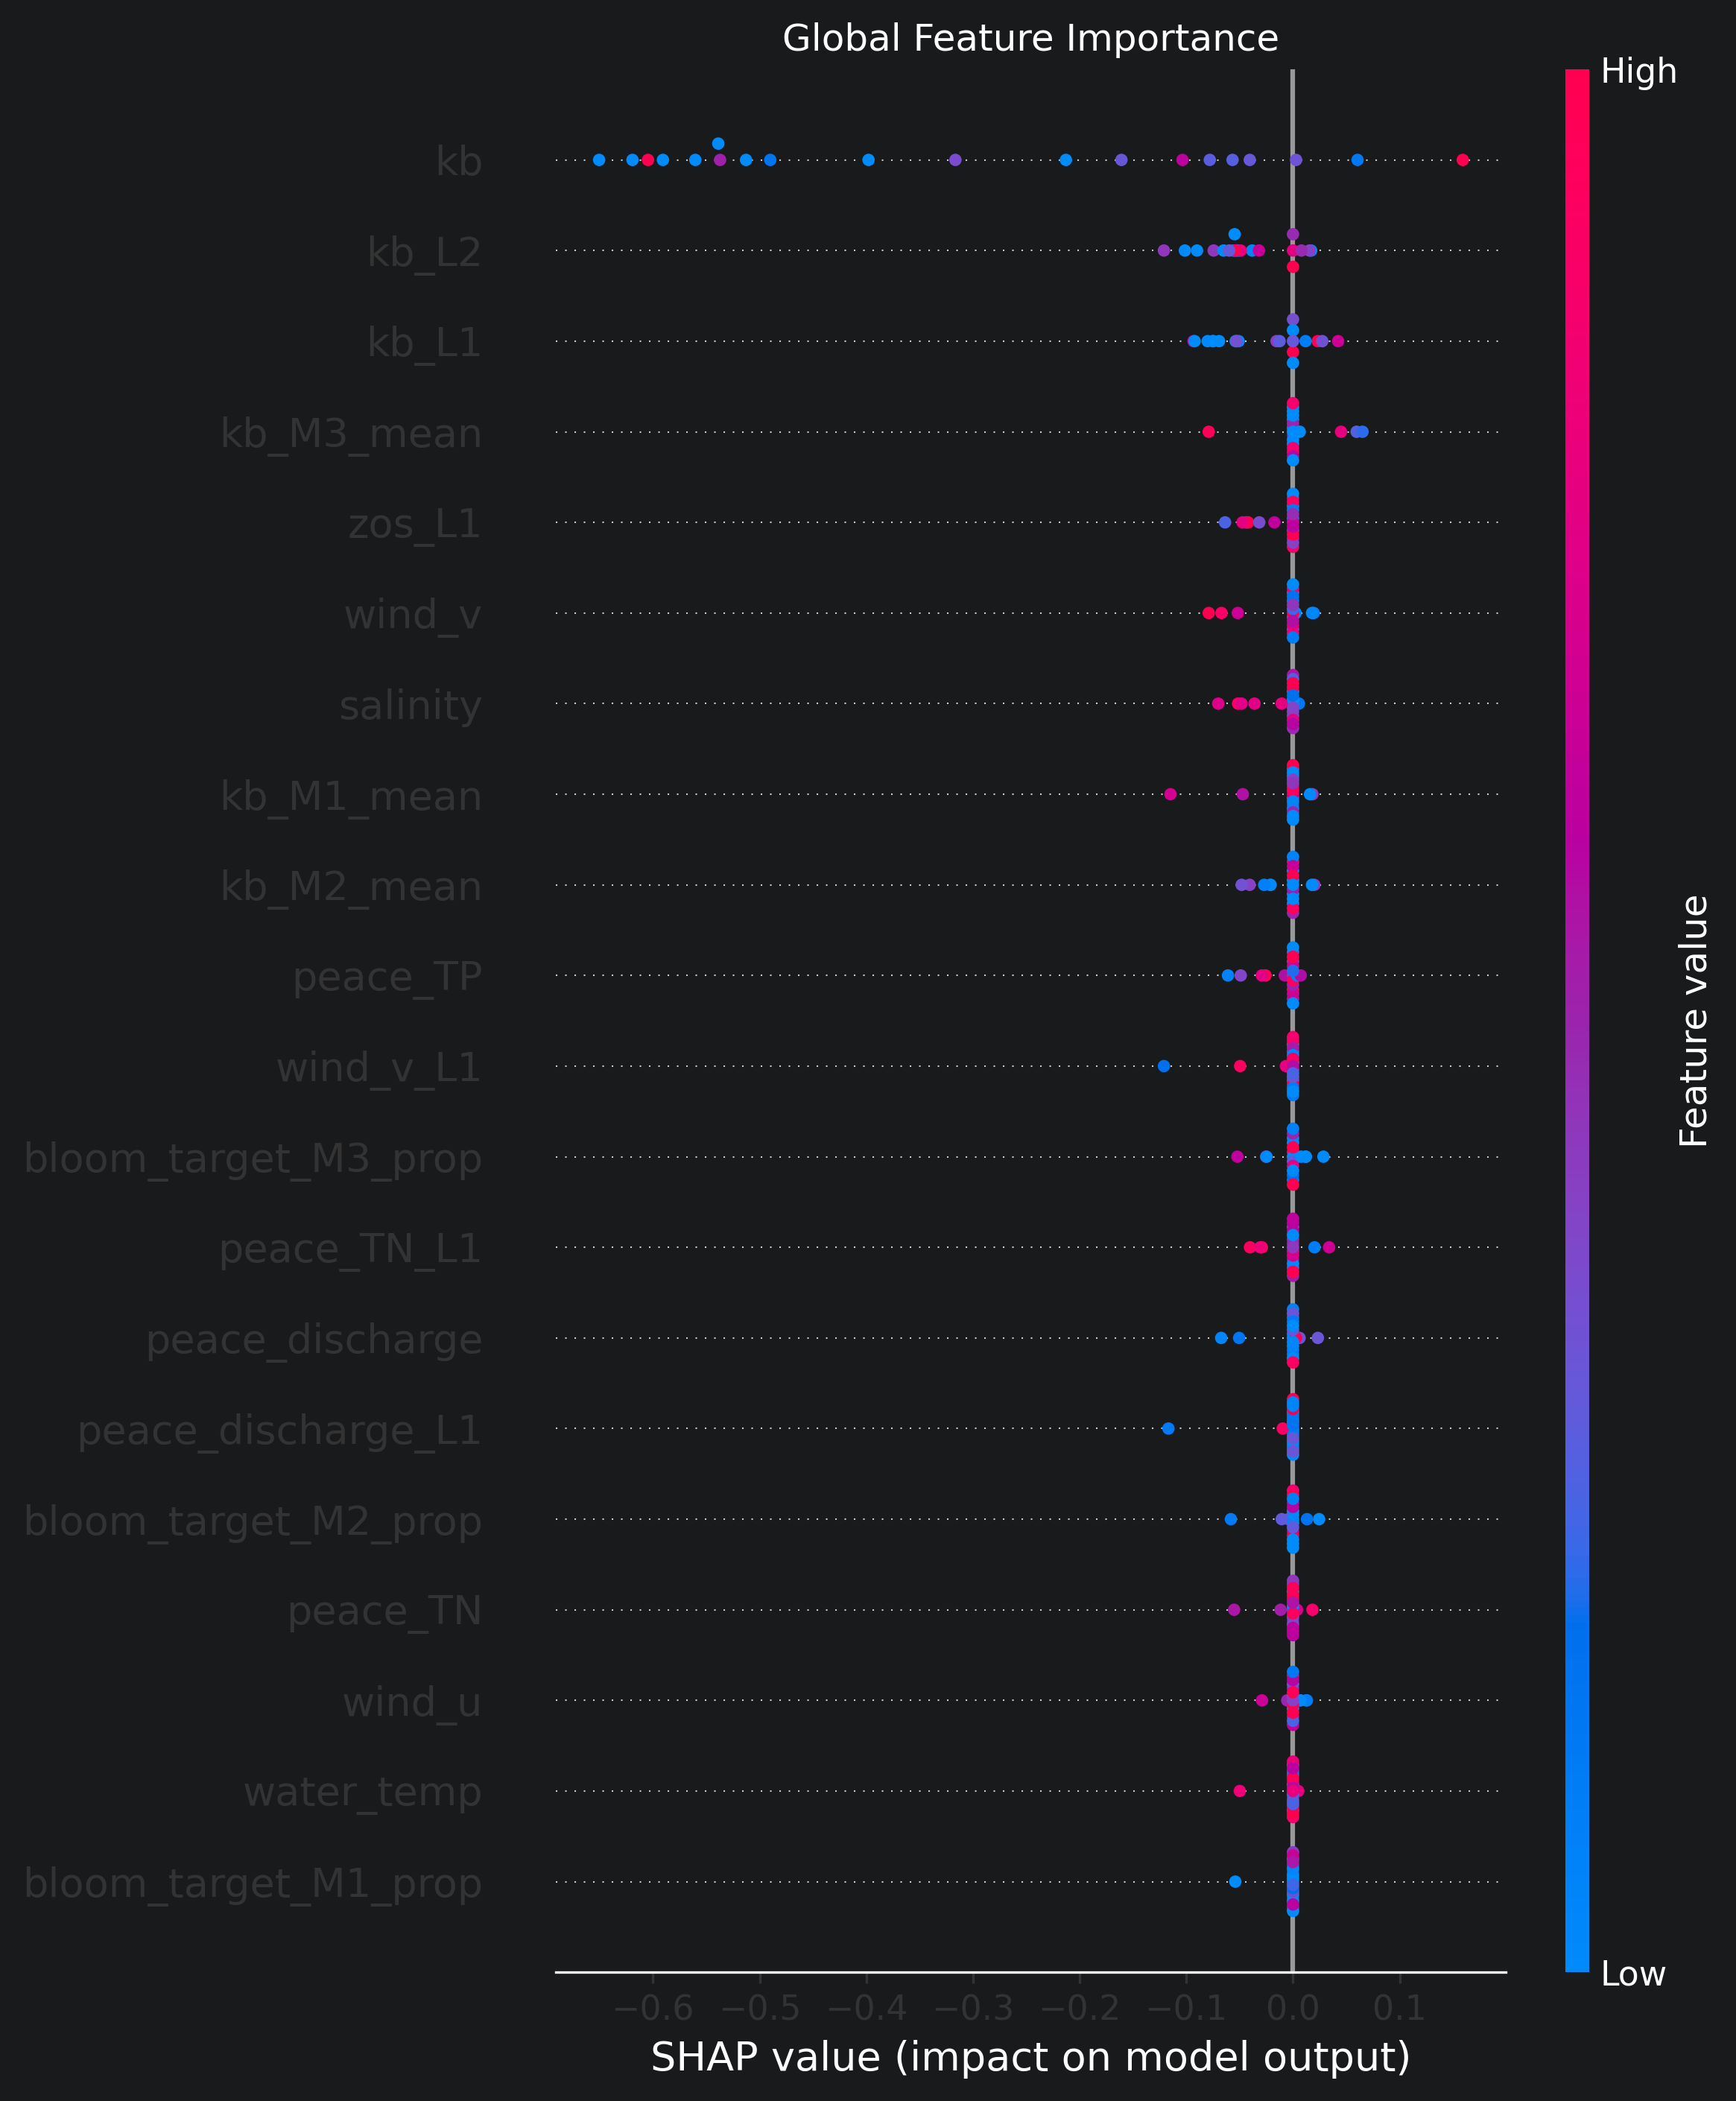

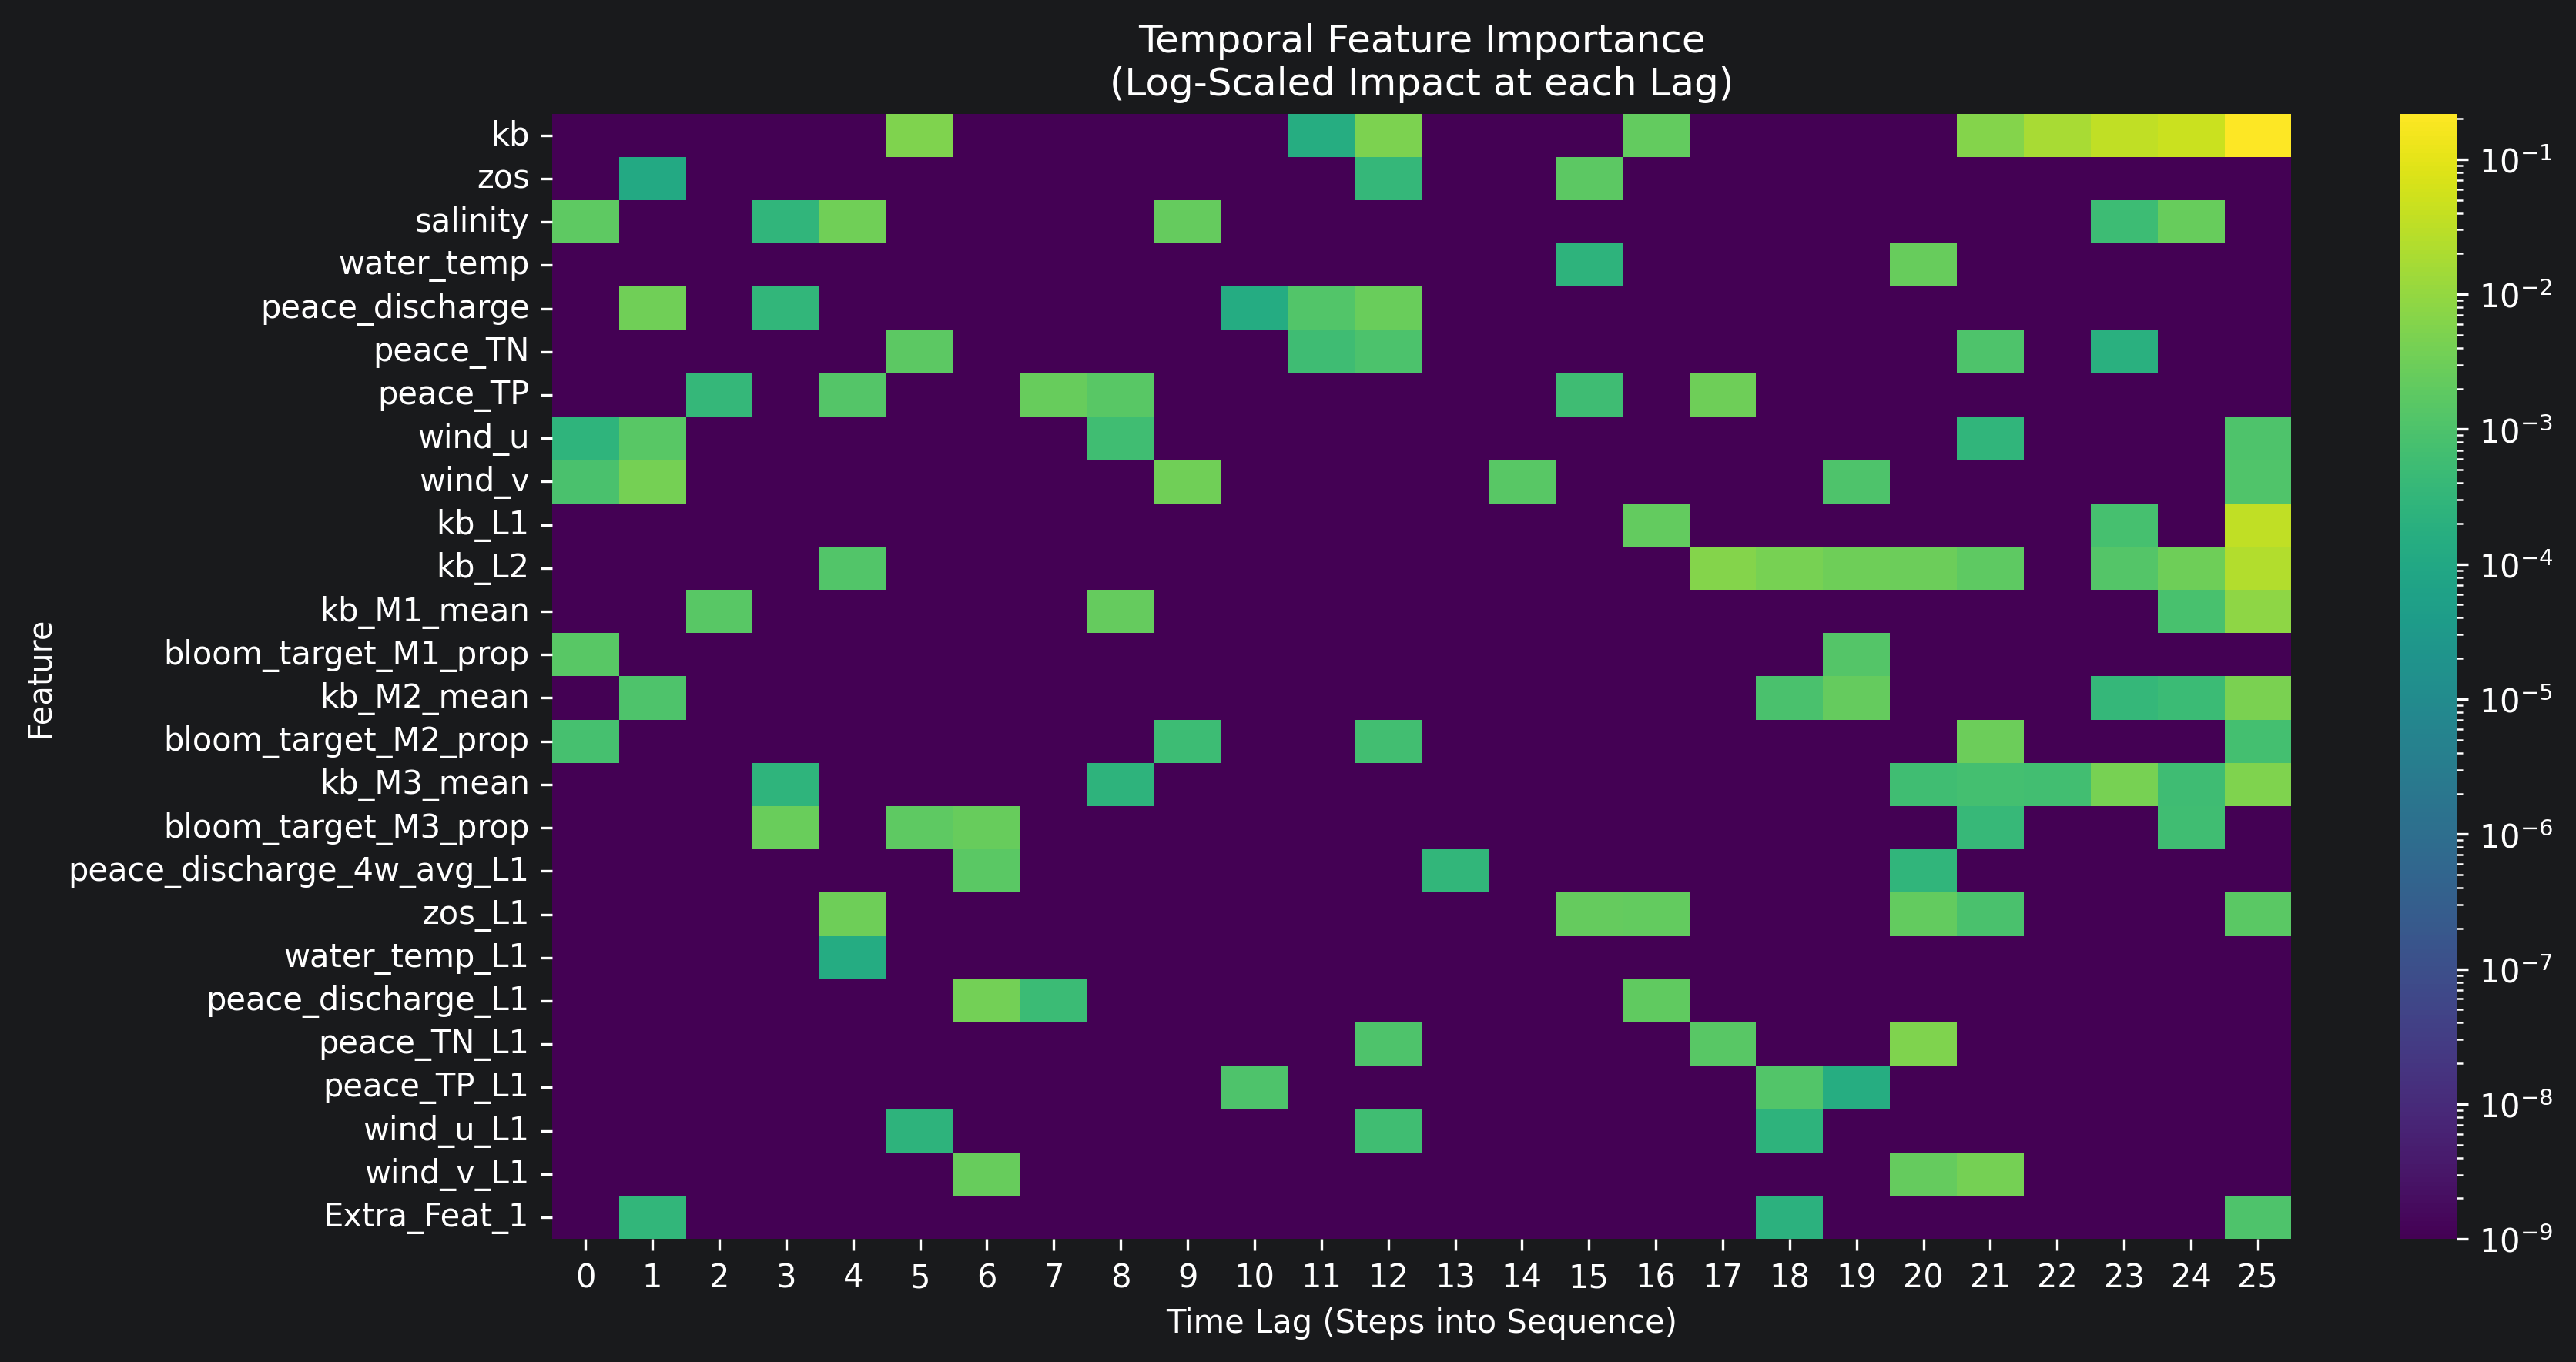

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
try:
    # 1. Check & Fix Data Dimensions
    # ---------------------------------------------------------
    if 'X_test' not in locals() or 'trained_model' not in locals():
        raise NameError("Data or Model missing. Please restart kernel and run Steps 1-9.")

    true_n_steps = X_test.shape[1]    # e.g., 12
    true_n_features = X_test.shape[2] # e.g., 26

    print(f"Data Shape: {true_n_steps} steps, {true_n_features} features")

    # Fix the feature name list if it doesn't match the data
    current_names = final_feature_columns_used if 'final_feature_columns_used' in locals() else []

    if len(current_names) != true_n_features:
        print(f"Mismatch: {len(current_names)} names vs {true_n_features} data features.")
        diff = true_n_features - len(current_names)
        # We assume the extra columns are usually appended at the end
        plotting_feature_names = current_names + [f"Extra_Feat_{i+1}" for i in range(diff)]
    else:
        plotting_feature_names = current_names

    # 2. Define Wrapper (The Fix)
    # ---------------------------------------------------------
    def model_wrapper(flat_data):
        """
        Converts flat SHAP input back to 3D and queries the model
        using Direct Call (not .predict) to avoid TF Graph errors.
        """
        # Convert Numpy -> Tensor
        # Reshape to (Samples, Time, Features)
        reshaped = flat_data.reshape(-1, true_n_steps, true_n_features)
        tensor_input = tf.convert_to_tensor(reshaped, dtype=tf.float32)

        # Direct call (Eager Mode) - Faster and safer for SHAP
        probs = trained_model(tensor_input, training=False)

        # Return as Numpy flattened array
        return probs.numpy().flatten()

    # 3. Optimize Background (K-Means)
    # ---------------------------------------------------------
    print("Summarizing background data...")
    # Flatten train data: (Samples, Time*Feats)
    X_train_flat = X_train.reshape(X_train.shape[0], -1)

    # Summarize training data into 10 weighted points (Centroids)
    background_summary = shap.kmeans(X_train_flat, 10)

    # 4. Initialize KernelExplainer
    # ---------------------------------------------------------
    print("Initializing KernelExplainer...")
    explainer = shap.KernelExplainer(model_wrapper, background_summary)

    # 5. Calculate SHAP Values
    # ---------------------------------------------------------
    explain_size = 20  # Keep small for speed
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # Pick random samples to explain
    idxs = np.random.choice(X_test_flat.shape[0], explain_size, replace=False)
    X_test_sample = X_test_flat[idxs]

    print(f"Calculating SHAP values for {explain_size} instances...")
    # nsamples=auto usually works best, or try 500 if slow
    shap_values = explainer.shap_values(X_test_sample, nsamples=500)

    print(f"SHAP calculation complete.")

    # 6. Reshape for Visualization
    # ---------------------------------------------------------
    # (Samples, Flat_Features) -> (Samples, Time, Features)
    shap_values_3d = np.array(shap_values).reshape(-1, true_n_steps, true_n_features)
    X_test_sample_3d = X_test_sample.reshape(-1, true_n_steps, true_n_features)

    # 7. PLOT A: Global Feature Importance
    # ---------------------------------------------------------
    # Sum SHAP impact across all time steps
    shap_sum_over_time = np.sum(shap_values_3d, axis=1) # (Samples, Features)
    features_mean = np.mean(X_test_sample_3d, axis=1)   # (Samples, Features)

    plt.figure(figsize=(10, 8), dpi=300)
    shap.summary_plot(shap_sum_over_time, features_mean,
                      feature_names=plotting_feature_names, show=False)
    plt.title("Global Feature Importance")
    plt.tight_layout()
    plt.savefig("output/shap_summary_global.png")
    plt.show()

    # 8. PLOT B: Temporal Heatmap
    # ---------------------------------------------------------
    # Average absolute impact per time step

    # Calculate the mean absolute SHAP impact per time step
    # temporal_importance shape will be (Time, Feats)
    temporal_importance = np.mean(np.abs(shap_values_3d), axis=0)

    # Initialize the figure using subplots for better control
    fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

    # We add a tiny epsilon (1e-9) to handle any zero values in the importance matrix,
    # as LogNorm requires strictly positive values to function correctly.
    epsilon = 1e-9

    # Generate the heatmap with LogNorm applied to the color scale
    sns.heatmap(
        temporal_importance.T + epsilon,
        cmap='viridis',
        norm=LogNorm(),
        yticklabels=plotting_feature_names,
        xticklabels=range(true_n_steps),
        ax=ax
    )

    # Refine labels and save the output
    ax.set_title("Temporal Feature Importance\n(Log-Scaled Impact at each Lag)")
    ax.set_xlabel("Time Lag (Steps into Sequence)")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig("output/shap_temporal_heatmap.png")



except Exception as e:
    print(f"❌ SHAP Failed: {e}")
    import traceback
    traceback.print_exc()

## Part 18: Time-Lagged Cross-Correlation (TLCC) Analysis

This section introduces **Time-Lagged Cross-Correlation (TLCC)** to investigate the dynamic relationships between environmental drivers and red tide concentrations. Unlike standard correlation, TLCC identifies leads and lags in the data, revealing how long it takes for a change in an environmental factor (like a nutrient spike) to manifest as a biological response (a bloom).

### Core Analytical Components

The analysis provides a temporal roadmap of the ecosystem's behavior, helping to validate the choice of lookback windows used in the LSTM model.

1. **Identifying Temporal Offsets:**
TLCC calculates the correlation between two time series—such as river discharge and *Karenia brevis* abundance—at various time shifts. By finding the "peak" correlation, we can determine the specific latency of the system. For example, if the peak correlation with Phosphorus occurs at a lag of 14 days, it suggests a two-week window for biological uptake and population growth.
2. **Directionality of Influence:**
By observing whether the peak correlation occurs at a positive or negative lag, we can confirm the causal direction. A positive lag (where the environmental variable precedes the bloom) confirms the variable as a leading indicator or "driver," whereas a zero lag suggests a simultaneous response.
3. **Stability and Seasonality:**
The analysis can be extended to **Windowed TLCC**, which evaluates how these correlations change over time. This is particularly relevant for Florida’s coastlines, where the relationship between rainfall and red tide may shift between the wet and dry seasons.

### Insights and Model Refinement

The results from this section serve as a critical bridge between data science and marine biology:

* **Feature Engineering Validation:** We use these findings to refine the `lag_days` parameters in Part 4, ensuring the model focuses on the most biologically relevant timeframes.
* **System Memory:** TLCC helps quantify the "memory" of the ecosystem, indicating how long an environmental disturbance continues to influence bloom dynamics.
* **Predictive Confidence:** Identifying features with strong, stable leads increases our confidence in the LSTM’s ability to provide early warnings before a bloom is visible in satellite or field data.

By incorporating TLCC, we move beyond static snapshots to a fluid, temporal understanding of the drivers behind red tide events.


--- Onset Latency Analysis (Threshold: 0.3) ---
Actual Bloom Starts found: 10
Predicted Bloom Starts found: 5
  Event at Week 0: Model is PERFECT by 0 weeks.
  Event at Week 56: MISSED COMPLETELY (No prediction within 4 weeks)
  Event at Week 84: MISSED COMPLETELY (No prediction within 4 weeks)
  Event at Week 89: Model is LATE by 2 weeks.
  Event at Week 98: MISSED COMPLETELY (No prediction within 4 weeks)
  Event at Week 154: Model is EARLY by 4 weeks.
  Event at Week 165: MISSED COMPLETELY (No prediction within 4 weeks)
  Event at Week 168: MISSED COMPLETELY (No prediction within 4 weeks)
  Event at Week 176: MISSED COMPLETELY (No prediction within 4 weeks)
  Event at Week 182: MISSED COMPLETELY (No prediction within 4 weeks)

>>> AVERAGE LATENCY: -0.67 Weeks
    (Negative = The model gives EARLY WARNING)


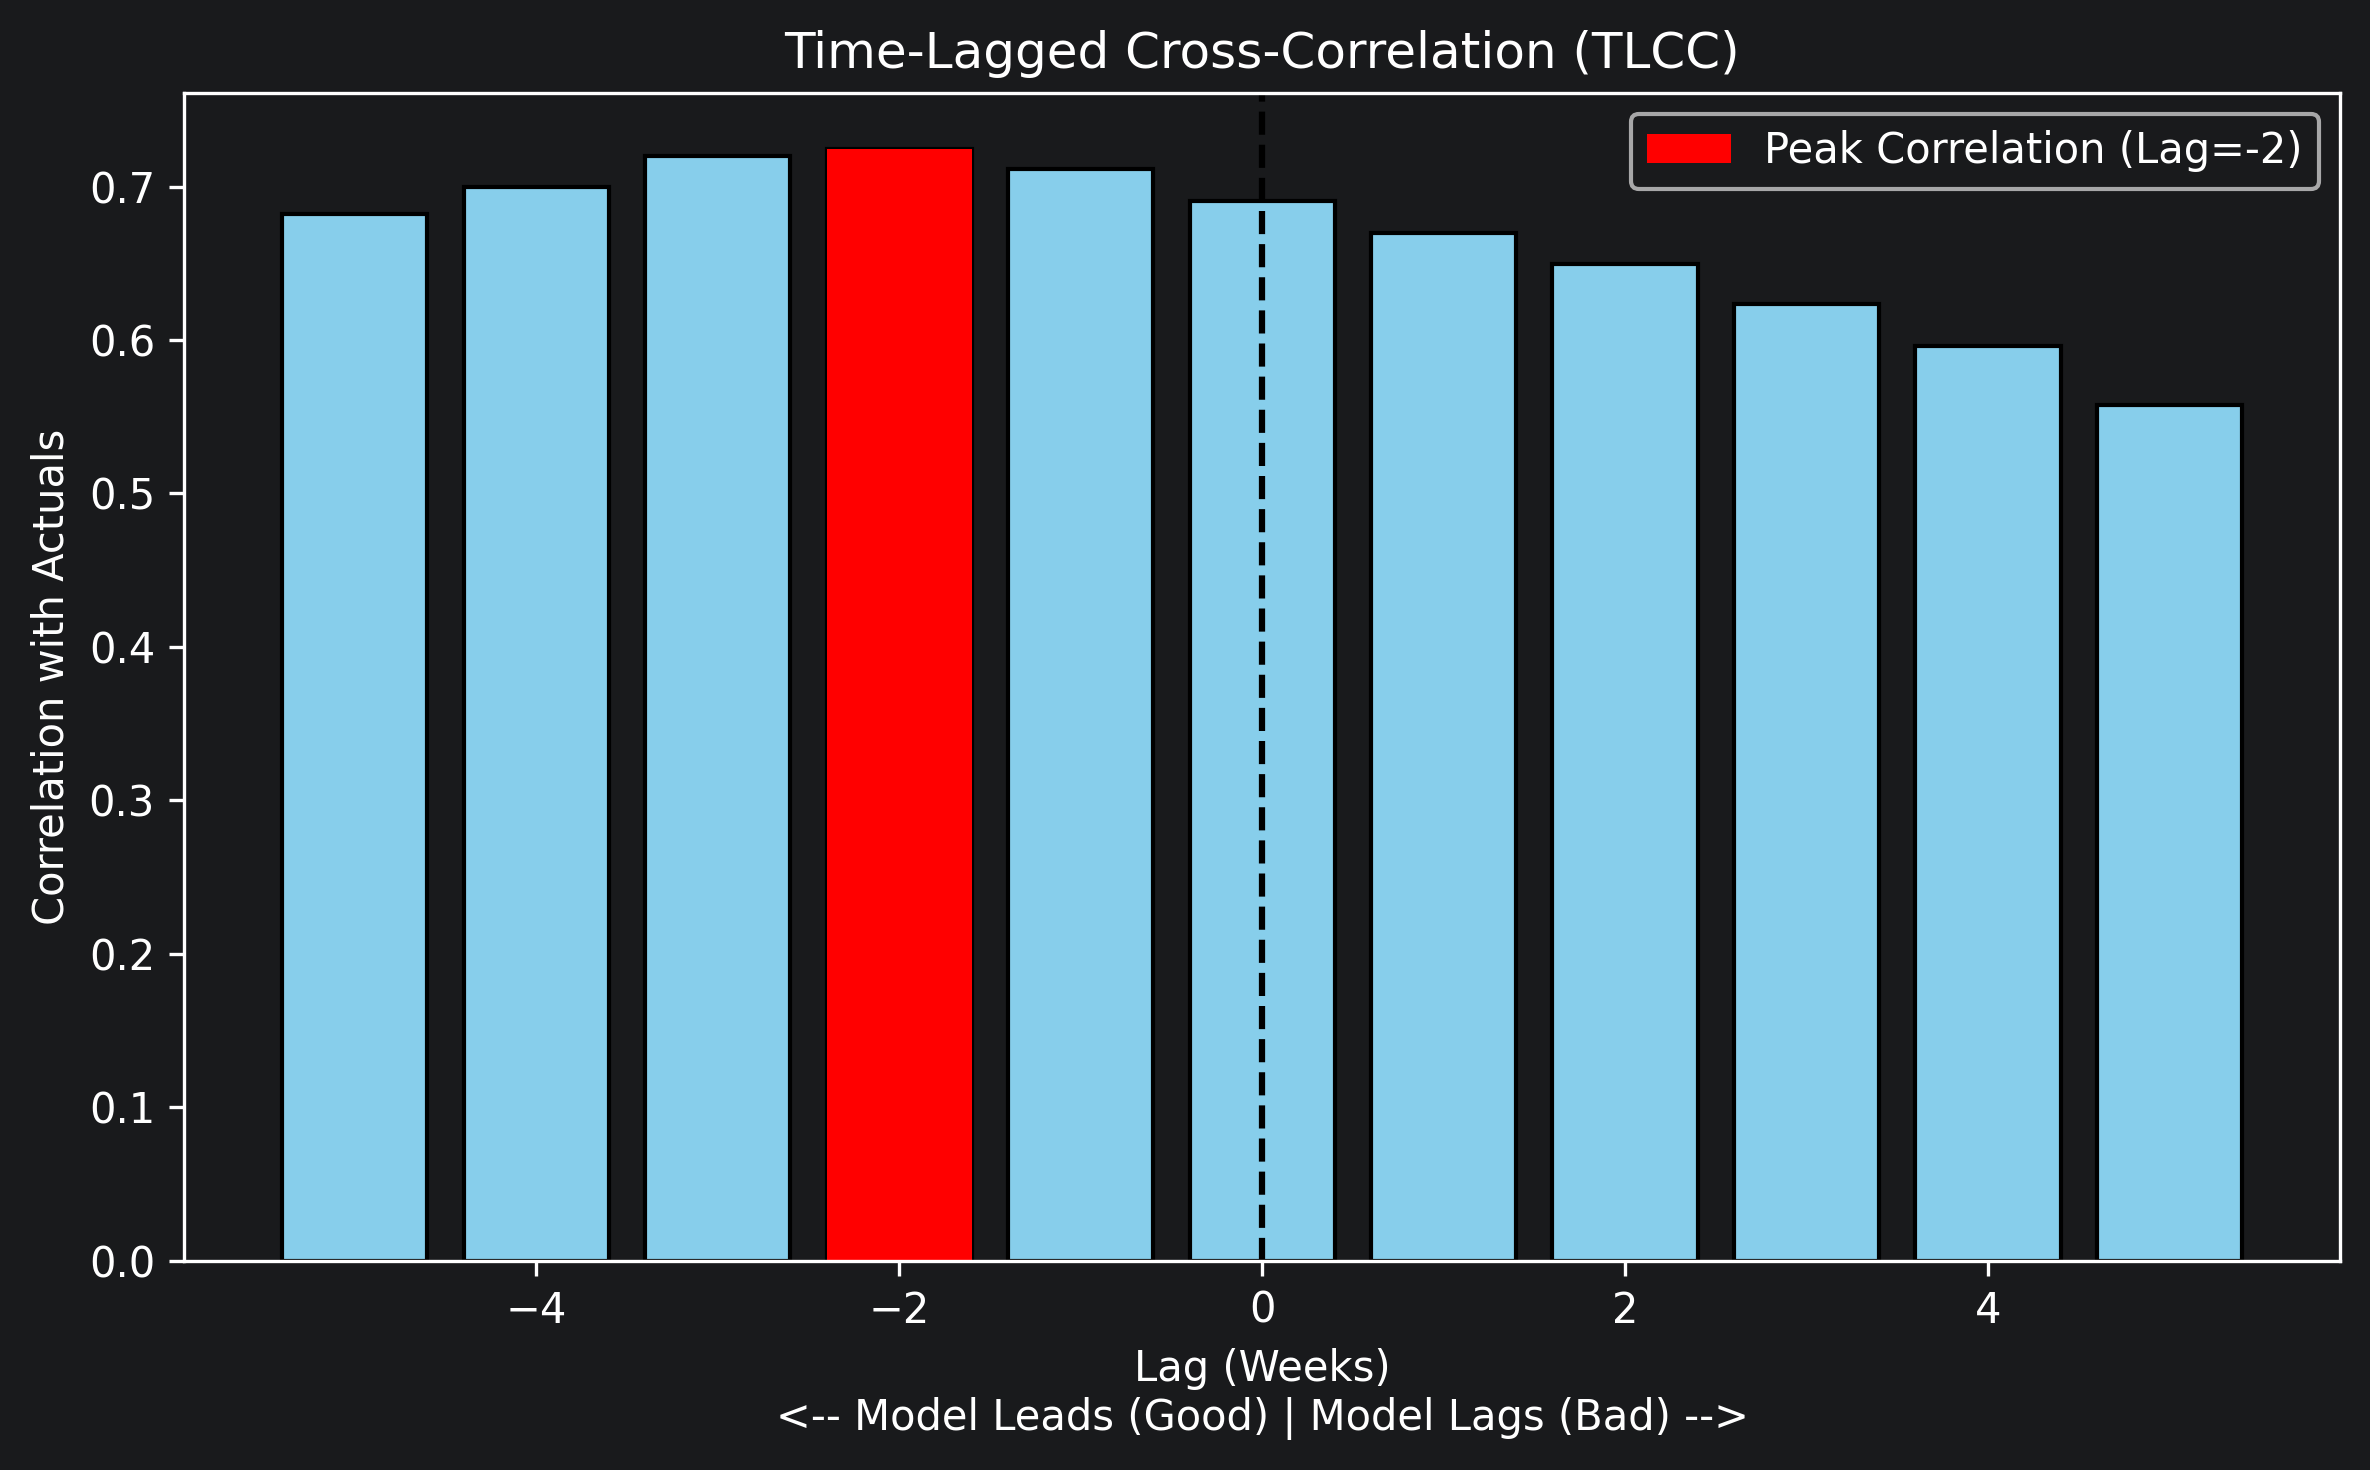

In [6]:
def analyze_onset_lag(y_true, y_pred_prob, threshold=0.3, tolerance=4):
    """pynb i
    Calculates exactly how many weeks late (or early) the model predicts blooms.

    Args:
        y_true: Binary actuals (0/1)
        y_pred_prob: Continuous probabilities (0.0-1.0)
        threshold: Decision threshold
        tolerance: Max weeks to look for a matching predicted onset
    """
    print(f"\n--- Onset Latency Analysis (Threshold: {threshold}) ---")

    y_pred_class = (y_pred_prob >= threshold).astype(int)

    # 1. Identify "Start" events (0 -> 1 transitions)
    # We use diff() to find where value changes from 0 to 1
    actual_onsets = np.where(np.diff(y_true, prepend=0) == 1)[0]
    pred_onsets = np.where(np.diff(y_pred_class, prepend=0) == 1)[0]

    print(f"Actual Bloom Starts found: {len(actual_onsets)}")
    print(f"Predicted Bloom Starts found: {len(pred_onsets)}")

    if len(actual_onsets) == 0:
        print("No blooms in test set to analyze.")
        return

    # 2. Match Actual Starts to Nearest Predicted Start
    lags = []

    for t_actual in actual_onsets:
        # Find predicted onsets within 'tolerance' weeks window
        # We look for the closest prediction around the actual event
        nearby_preds = pred_onsets[np.abs(pred_onsets - t_actual) <= tolerance]

        if len(nearby_preds) > 0:
            # Find the closest one
            closest_pred = nearby_preds[np.argmin(np.abs(nearby_preds - t_actual))]

            # Lag = Predicted Time - Actual Time
            # Positive = Late (Lag)
            # Negative = Early Warning (Lead)
            lag = closest_pred - t_actual
            lags.append(lag)

            status = "LATE" if lag > 0 else "EARLY" if lag < 0 else "PERFECT"
            print(f"  Event at Week {t_actual}: Model is {status} by {abs(lag)} weeks.")
        else:
            print(f"  Event at Week {t_actual}: MISSED COMPLETELY (No prediction within {tolerance} weeks)")
            lags.append(np.nan) # Missed event

    # 3. Summary Stats
    lags_clean = [l for l in lags if not np.isnan(l)]
    if lags_clean:
        avg_lag = np.mean(lags_clean)
        print(f"\n>>> AVERAGE LATENCY: {avg_lag:.2f} Weeks")
        if avg_lag > 0:
            print("    (Positive = The model is LAGGING)")
        else:
            print("    (Negative = The model gives EARLY WARNING)")
    else:
        print("\n>>> No matched events found.")

    # 4. Visualizing the Lag
    # Cross-Correlation Plot (Statistical Proof)
    # Shift predictions back/forward and see where correlation is highest
    shifts = range(-5, 6) # Shift -5 to +5 weeks
    correlations = []
    for s in shifts:
        # Shift predicted probabilities
        if s < 0:
            p_shifted = y_pred_prob[-s:]
            y_shifted = y_true[:s]
        elif s > 0:
            p_shifted = y_pred_prob[:-s]
            y_shifted = y_true[s:]
        else:
            p_shifted = y_pred_prob
            y_shifted = y_true

        # Calculate correlation
        if len(y_shifted) > 0:
            corr = np.corrcoef(y_shifted, p_shifted)[0, 1]
            correlations.append(corr)
        else:
            correlations.append(0)

    plt.figure(figsize=(8, 5), dpi=300)
    plt.bar(shifts, correlations, color='skyblue', edgecolor='black')

    # Highlight the max
    max_idx = np.argmax(correlations)
    best_lag = shifts[max_idx]
    plt.bar(best_lag, correlations[max_idx], color='red', label=f'Peak Correlation (Lag={best_lag})')

    plt.title("Time-Lagged Cross-Correlation (TLCC)")
    plt.xlabel("Lag (Weeks)\n<-- Model Leads (Good) | Model Lags (Bad) -->")
    plt.ylabel("Correlation with Actuals")
    plt.axvline(0, color='black', linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.savefig("output/lag_analysis.png")
    plt.show()

# --- Execute ---
if __name__ == "__main__":
    if 'mc_preds' in locals() and 'y_test_trimmed' in locals():
        # Get mean probs
        probs = np.mean(mc_preds, axis=1)

        # Run with your chosen threshold (e.g., 0.3)
        analyze_onset_lag(y_test_trimmed.flatten(), probs.flatten(), threshold=0.3)

## Part 19: EnKF Sensitivity Analysis

Assesses the robustness of the hybrid model's classification performance to perturbations in the two most consequential EnKF tuning choices — the process noise covariance `Q` and the ensemble size `N`. Each configuration is evaluated by re-running the full EnKF + MC-dropout forecasting pipeline on the test set and re-computing the optimal F1 threshold, so comparisons are like-for-like.

* **Experiment A — Q-scaling sensitivity:** Multiplies the baseline `Q` diagonal by {0.25, 0.5, 1.0, 2.0, 5.0}× at fixed `N = 50`.
* **Experiment B — Ensemble size sensitivity:** Sweeps `N ∈ {25, 50, 100, 200}` at baseline `Q` and `R`.
* **Reported metrics:** accuracy, precision, recall, F1, Brier score, and onset hit rate for each configuration; the baseline configuration is flagged for reference.
* **Purpose:** supports the manuscript claim that classification performance is stable under moderate perturbations of the assimilation parameters, with results tabulated in Supplementary Tables S1–S2.

In [7]:
# --- EnKF-preprocessor sensitivity provenance ---
# A fair Q/R or ensemble-size sensitivity study for this design requires
# regenerating notebook 01 artifacts and retraining notebook 03 models for each
# setting. This notebook records the baseline EnKF configuration and leaves the
# sensitivity tables empty rather than reporting test-only preprocessing changes.
with open(ENKF_PREPROCESSOR_NOISE_PATH) as f:
    enkf_preprocessor_config = json.load(f)

sensitivity_results_q = {}
sensitivity_results_n = {}
sensitivity_results_propagator = {}
sensitivity_results_note = {
    "design": "EnKF is a causal preprocessor applied before sequence creation.",
    "reason_sensitivity_not_run_here": (
        "Changing Q/R or N changes the training data distribution. A fair "
        "sensitivity sweep must rerun notebooks 01-04 for each setting."
    ),
    "baseline_config": enkf_preprocessor_config,
}

print(json.dumps(sensitivity_results_note, indent=2))


{
  "design": "EnKF is a causal preprocessor applied before sequence creation.",
  "reason_sensitivity_not_run_here": "Changing Q/R or N changes the training data distribution. A fair sensitivity sweep must rerun notebooks 01-04 for each setting.",
  "baseline_config": {
    "state_vars": [
      "peace_discharge",
      "peace_TN",
      "peace_TP",
      "kb",
      "wind_u",
      "wind_v"
    ],
    "Q_diag": [
      45521.68448349423,
      0.09266185758693707,
      0.00749692338522224,
      1265578898015.9841,
      0.12709667340396316,
      0.23980725008718512
    ],
    "R_diag": [
      569021.0560436778,
      1.1582732198367134,
      0.093711542315278,
      1265578898015.9841,
      1.5887084175495394,
      2.997590626089814
    ],
    "n_enkf": 50,
    "obs_noise_frac": 0.25,
    "proc_noise_frac": 0.02,
    "protect_vars": [
      "kb"
    ],
    "protect_obs_frac": 0.02,
    "append_std": true
  }
}


In [8]:
# =============================================================================
# Part 20: Propagator Sensitivity Experiment (Experiment C)
# =============================================================================
# Adds a third sensitivity dimension alongside Part 19's Q-scaling
# (Experiment A) and ensemble-size (Experiment B) sweeps: the driver
# propagation model used inside the EnKF forecast step. Compares the
# random-walk baseline against AR(1), VAR(1), and seasonal+AR(1)
# propagators, all fit on train_df only. Results feed into
# `sensitivity_export['propagator']` so notebook 07 can render them as
# Supplementary Table S4 without further plumbing.
# =============================================================================

import json
import importlib
import enkf_utils

# Reload so an already-running notebook kernel sees the function added to enkf_utils.py.
importlib.reload(enkf_utils)
from enkf_utils import run_propagator_sensitivity_experiment

required = ['trained_model', 'X_test', 'y_test', 'test_df', 'train_df',
            'scaler', 'final_feature_columns_used']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"Error: Missing variables: {missing}")
    print("Run Parts 1-13 first, then this cell.")
else:
    sensitivity_results_propagator = run_propagator_sensitivity_experiment(
        trained_model     = trained_model,
        X_test            = X_test,
        y_test            = y_test,
        test_df           = test_df,
        train_df          = train_df,
        scaler            = scaler,
        feature_columns   = final_feature_columns_used,
        enkf_state_vars   = ENKF_STATE_VARS,
        seq_len           = SEQUENCE_LENGTH,
        n_ensemble        = N_ENKF,
        n_mc              = N_MC_SAMPLES,
        Q_baseline_diag   = MANUAL_Q_DIAG,
        R_baseline_diag   = MANUAL_R_DIAG,
    )


EXPERIMENT C: Legacy test-time EnKF propagator sensitivity
Note: the primary pipeline now uses EnKF as a preprocessor. Treat these
      results as a legacy diagnostic unless you retrain per propagator.

--- Propagator: RandomWalk ---

--- Setting up EnKF ---
Initial State Vector (t=0): [ 1.39207563e+03  1.86922676e+00  1.06237770e+00  1.04461770e+07
 -7.22328144e+00 -1.19789407e+00]
-> Using MANUAL R Matrix values.
-> Using MANUAL Q Matrix values.
Noise Matrices Finalized:
  R (Obs Noise) diag: [1.00e+00 4.00e-06 4.00e-08 6.25e-02 6.25e-02 1.00e-06]
  Q (Proc Noise) diag: [9.00e+04 3.60e-01 3.60e-03 2.25e+02 2.25e+02 1.00e-02]
EnKF Initialized. Members: 50, State Dim: 6


RandomWalk:   0%|          | 0/216 [00:00<?, ?it/s]

  acc=0.875 prec=0.759 rec=0.900 f1=0.824 brier=0.1025 threshold=0.596

--- Propagator: AR1 ---

--- Setting up EnKF ---
Initial State Vector (t=0): [ 1.39207563e+03  1.86922676e+00  1.06237770e+00  1.04461770e+07
 -7.22328144e+00 -1.19789407e+00]
-> Using MANUAL R Matrix values.
-> Using MANUAL Q Matrix values.
Noise Matrices Finalized:
  R (Obs Noise) diag: [1.00e+00 4.00e-06 4.00e-08 6.25e-02 6.25e-02 1.00e-06]
  Q (Proc Noise) diag: [9.00e+04 3.60e-01 3.60e-03 2.25e+02 2.25e+02 1.00e-02]
EnKF Initialized. Members: 50, State Dim: 6


AR1:   0%|          | 0/216 [00:00<?, ?it/s]

C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)


...

  acc=0.903 prec=0.802 rec=0.929 f1=0.861 brier=0.0974 threshold=0.637

--- Propagator: SeasonalAR1 ---

--- Setting up EnKF ---
Initial State Vector (t=0): [ 1.39207563e+03  1.86922676e+00  1.06237770e+00  1.04461770e+07
 -7.22328144e+00 -1.19789407e+00]
-> Using MANUAL R Matrix values.
-> Using MANUAL Q Matrix values.
Noise Matrices Finalized:
  R (Obs Noise) diag: [1.00e+00 4.00e-06 4.00e-08 6.25e-02 6.25e-02 1.00e-06]
  Q (Proc Noise) diag: [9.00e+04 3.60e-01 3.60e-03 2.25e+02 2.25e+02 1.00e-02]
EnKF Initialized. Members: 50, State Dim: 6


SeasonalAR1:   0%|          | 0/216 [00:00<?, ?it/s]

C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)
C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)


  acc=0.898 prec=0.793 rec=0.929 f1=0.855 brier=0.1000 threshold=0.629


C:\Users\victo\PycharmProjects\ENKF\enkf_utils.py:499: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  noise = np.random.multivariate_normal(np.zeros(dim), Q_matrix, size=enkf.N)


## Persist analysis outputs

In [9]:
import json

# Bootstrap results (Part 16)
bootstrap_export = {}
for cand in ('bootstrap_ci', 'bootstrap_results', 'ci_results', 'bootstrap_summary'):
    if cand in dir():
        d = eval(cand)
        if isinstance(d, dict):
            # Coerce np types to plain Python for json
            def _coerce(v):
                if isinstance(v, dict): return {k: _coerce(x) for k, x in v.items()}
                if isinstance(v, (list, tuple)): return [_coerce(x) for x in v]
                if isinstance(v, np.ndarray): return v.tolist()
                if isinstance(v, (np.floating,)): return float(v)
                if isinstance(v, (np.integer,)):  return int(v)
                return v
            bootstrap_export = _coerce(d)
            break

bs_path = os.path.join(INTERMEDIATE_DIR, 'bootstrap_results.json')
with open(bs_path, 'w') as f:
    json.dump(bootstrap_export, f, indent=2)
print(f"Wrote {bs_path}")

# Sensitivity results (Parts 19 + 20)
def _coerce_for_json(d):
    """Convert numpy types and tuple keys to JSON-safe values."""
    if isinstance(d, dict):
        return {str(k): _coerce_for_json(v) for k, v in d.items()}
    if isinstance(d, (list, tuple)):
        return [_coerce_for_json(v) for v in d]
    if isinstance(d, np.ndarray):
        return d.tolist()
    if isinstance(d, (np.floating,)):
        return float(d)
    if isinstance(d, (np.integer,)):
        return int(d)
    return d

sensitivity_export = {}
if 'sensitivity_results_note' in dir():
    sensitivity_export['note'] = _coerce_for_json(sensitivity_results_note)
    print('  Saving EnKF-preprocessor sensitivity note')
if 'sensitivity_results_q' in dir():
    sensitivity_export['q_scaling']     = _coerce_for_json(sensitivity_results_q)
    print(f"  Saving sensitivity_results_q with {len(sensitivity_results_q)} Q values")
if 'sensitivity_results_n' in dir():
    sensitivity_export['ensemble_size'] = _coerce_for_json(sensitivity_results_n)
    print(f"  Saving sensitivity_results_n with {len(sensitivity_results_n)} N values")
if 'sensitivity_results_propagator' in dir():
    sensitivity_export['propagator']    = _coerce_for_json(sensitivity_results_propagator)
    print(f"  Saving sensitivity_results_propagator with {len(sensitivity_results_propagator)} propagators")

with open(SENSITIVITY_RESULTS_PATH, 'w') as f:
    json.dump(sensitivity_export, f, indent=2)
print(f"Wrote {SENSITIVITY_RESULTS_PATH}")

# Standalone propagator JSON (mirrors the bootstrap_results.json / sensitivity_results.json
# pattern — lets notebook 07 read propagator results directly without parsing the master dict).
if 'sensitivity_results_propagator' in dir():
    with open(PROPAGATOR_RESULTS_PATH, 'w') as f:
        json.dump(_coerce_for_json(sensitivity_results_propagator), f, indent=2)
    print(f"Wrote {PROPAGATOR_RESULTS_PATH}")

Wrote output_refactored/intermediate\bootstrap_results.json
  Saving EnKF-preprocessor sensitivity note
  Saving sensitivity_results_q with 0 Q values
  Saving sensitivity_results_n with 0 N values
  Saving sensitivity_results_propagator with 4 propagators
Wrote output_refactored/intermediate\sensitivity_results.json
Wrote output_refactored/intermediate\propagator_sensitivity_results.json
